## General Instructions
---

1. This lab must be completed **individually**.

2. You may use the following libraries:
   - seaborn  
   - matplotlib  
   - pandas  
   - numpy  
   - csv  
   - scikit
  
   However, you are **NOT** allowed to use the direct inbuilt classifier functions.

3. All code must be submitted in the form of a **single Jupyter notebook**.

4. Marks for each sub-section are mentioned in the respective questions.

5. You may use **Google Colab** to run the Jupyter notebook  
   (https://colab.research.google.com/).  
   References for loading data in Colab:
   - https://towardsdatascience.com/3-ways-to-load-csv-files-into-colab-7c14fcbdcb92  
   - https://www.marktechpost.com/2019/06/07/how-to-connect-google-colab-with-google-drive/  
   Alternatively, you may run the notebook locally using **Anaconda Jupyter Notebook**.

6. The lab must be submitted on **Google Classroom**.  
   Please make sure to run the cells before submitting so that the outputs are visible.

7. **Code readability is very important.**  
   - Modularize your code using functions and/or classes  
   - Use self-explanatory variable names  
   - Add comments to clearly describe your approach  
   - You may add additional code or text cells wherever necessary

8. You are expected to submit your **observations**, and not just an error-free implementation.

9. Students are expected to strictly follow the **honor code** of the class.

10. The deadline is **strict**. Assignments submitted after the deadline will not be considered for evaluation unless prior permission is obtained at least **4 days before** the submission deadline.

11. Marks will be awarded based on:
    - Quality of code
    - Use of innovative data structures
    - Scalability
    - Correctness
    - Completeness and clarity of reported observations

12. In case of any queries regarding **Lab 2**, please contact the TAs via email (details provided on Google Classroom).

13. Fix the random seed value to **42** to ensure reproducibility of results.

14. You may choose any appropriate learning rate of your choice for training the models.

# Task 1: Experimental Analysis of Logistic Regression Variants

### Dataset

We will use the **Car Evaluation Dataset** from the UCI Machine Learning Repository:

https://archive.ics.uci.edu/ml/datasets/car+evaluation

The dataset contains **1,728 samples**, described using **six categorical attributes**:
- `buying`
- `maint`
- `doors`
- `persons`
- `lug_boot`
- `safety`

Target Variable (Ordinal)

The original class labels are:

$$\text{unacc} < \text{acc} < \text{good} < \text{vgood}$$
For this assignment, convert them into **three ordered classes**:
$$\text{Low} \rightarrow \text{unacc}, \quad \text{Medium} \rightarrow \text{acc}, \quad \text{High} \rightarrow \text{good} + \text{vgood}$$
Thus, the final label space is:
$$y \in \{1, 2, 3\} \quad (\text{Low} < \text{Medium} < \text{High})$$


### **Part 1(a): Data Preparation and Ordinal Structure Exploration [1+0.5+0.5 = 2 marks]**

1. Load the dataset and perform suitable preprocessing:
   - Encode categorical features (One-hot encoding)
2. Show the distribution of samples across the three ordinal classes.
3. **Observations to report:**
   - Class imbalance (if any)
   - Degree of overlap between adjacent ordinal classes (Low–Medium, Medium–High)
   For each feature:
   - Make one bar plot per class
   - Visually compare Low vs Medium, Medium vs High
   If bars look similar $\Rightarrow$ overlap; if bars look different $\Rightarrow$ separation.


### **Part 1(b): Linear Classifier [2+1+1 = 4 marks]**

Implement the Linear Classifier and visualize the classified samples based on the `buying` and `maint` features. Mark the misclassified samples with a different color. Report your observations.

### **Part 2: One-vs-Rest Logistic Regression [2+1+0.5+0.5+1 = 5 marks]**

Since logistic regression is inherently binary, multi-class problems are often handled using **One-vs-Rest (OvR)**.
In OvR, one binary classifier is trained per class:
$$P(y = k \mid \mathbf{x}) = \sigma\!\left(\mathbf{w}_k^\top \mathbf{x} + b_k\right)$$
Prediction rule:
$$\hat{y} = \arg\max_k \; P(y = k \mid \mathbf{x})$$
One-vs-Rest trains one yes/no classifier per class and predicts the class whose classifier is most confident.
Tasks:
1. Implement OvR logistic regression.
2. Train using an **80–20 train–test split**.
3. Report:
   - Training accuracy
   - Testing accuracy
4. Plot the **confusion matrix**.
5. **Observations to report:**
   - Which class is most frequently misclassified?
   - Are extreme errors (Low $\leftrightarrow$ High) common?


### **Part 3: Effect of Regularization (L1 vs L2) [4+2+1+2 = 10 marks]**

Regularization is used to control overfitting and feature dependence.

Ridge (L2) Logistic Regression:
$$\mathcal{L} = -\sum_i \log P(y_i \mid \mathbf{x}_i) + \lambda \|\mathbf{w}\|_2^2$$

Lasso (L1) Logistic Regression:
$$\mathcal{L} = -\sum_i \log P(y_i \mid \mathbf{x}_i) + \lambda \|\mathbf{w}\|_1$$

Tasks:
1. Extend OvR logistic regression with:
   - L2 regularization
   - L1 regularization
2. Train both models with identical settings.
3. Report:
   - Training accuracy
   - Testing accuracy
4. **Observations to report:**
   - Effect of L1 vs L2 on sparsity
   - Impact on generalization performance


### **Part 4: Ordinal Logistic Regression [7+1+1+3 = 12 marks]**

Ordinal logistic regression explicitly models the ordering of class labels.
For a 3-class problem, the model learns:
- A single weight vector $\mathbf{w}$
- Two ordered thresholds $\theta_1 < \theta_2$

Cumulative Probability Model:
$$P(y \leq 1 \mid \mathbf{x}) = \sigma\!\left(\theta_1 - \mathbf{w}^\top \mathbf{x}\right)$$
$$P(y \leq 2 \mid \mathbf{x}) = \sigma\!\left(\theta_2 - \mathbf{w}^\top \mathbf{x}\right)$$

Ordinal logistic regression is trained by jointly learning a shared weight vector and ordered thresholds. The weight vector is typically initialized to zeros (or small random values), and the thresholds are initialized as ordered constants (e.g., $\theta_1 = 0$ and $\theta_2 = 1$). The weights map input features to a single score, while the thresholds split this score into ordered class regions. Both weights and thresholds are updated via gradient descent by minimizing the negative log-likelihood, while ensuring the ordering constraint $\theta_1 < \theta_2$ is preserved.

Class Probabilities:

$$P(y = 1) = P(y \leq 1)$$
$$P(y = 2) = P(y \leq 2) - P(y \leq 1)$$
$$P(y = 3) = 1 - P(y \leq 2)$$

Tasks:
1. Implement ordinal logistic regression using the cumulative logit formulation.
2. Train using the same data split as previous parts.
3. Evaluate using:
   - Accuracy
   - Mean Absolute Error (MAE)
4. **Observations to report:**
   - Are extreme errors (Low $\leftrightarrow$ High) reduced?
   - Comment on ordinal consistency of predictions. Are the model's predictions aligned with the natural ordering of the classes, or does it behave as if the classes were unrelated categories?


### **Part 5: Analysis [1+1+1 = 3 marks]**

Summarize and compare all models (variants of logistic regression and linear model) with respect to:
- Accuracy
- Ordinal error behavior
- Suitability for ordered labels

In [2]:
# Part 1(A) : Data Loading and Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

'''
buying : purchase price of car (low, med, high, vhigh)
maint : maintenance cost (low, med, high, vhigh)
doors : number of doors (2, 3, 4, 5more)
persons : passenger capacity (2, 4, more)
lug_boot : luggage size (small, med, big)
safety : safety level (low, med, high)
'''

df = pd.read_csv("car.data", names = columns)
print("Table before any changes : ")
print(df.head())
print(df.index)

mapping_a = {
    "unacc" : "Low",
    "acc" : "Medium",
    "good" : "High",
    "vgood" : "High"
}

for i in df.index:
    df.loc[i, "class"] = mapping_a[df.loc[i, "class"]]

print("Table after mapping_a : ")
print(df.head())


mapping_b = {
    "Low" : 1,
    "Medium" : 2,
    "High" : 3
}

for i in df.index:
    df.loc[i, "label"] = mapping_b[df.loc[i, "class"]]

print("Table after mapping_b :")
print(df.head())

df["class"].value_counts()


Table before any changes : 
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
RangeIndex(start=0, stop=1728, step=1)
Table after mapping_a : 
  buying  maint doors persons lug_boot safety class
0  vhigh  vhigh     2       2    small    low   Low
1  vhigh  vhigh     2       2    small    med   Low
2  vhigh  vhigh     2       2    small   high   Low
3  vhigh  vhigh     2       2      med    low   Low
4  vhigh  vhigh     2       2      med    med   Low
Table after mapping_b :
  buying  maint doors persons lug_boot safety class  label
0  vhigh  vhigh     2       2    small    low   Low    1.0
1  vhigh  vhigh     2       2    small    med   Low    1.0
2  vhigh  vhigh     2       2    small   high   Low    1.0
3  vhigh  vhigh   

class
Low       1210
Medium     384
High       134
Name: count, dtype: int64

In [3]:
# Part 1(A) : One Hot Encoding

# we have to convert each category into binary features
X = pd.get_dummies(df[["buying","maint","doors","persons","lug_boot","safety"]])
y = df['label'].values.astype(int)

print(X.columns)
feature_names = X.columns
print(X.head())
print(X.shape)
'''
Attribute Values

   buying       v-high, high, med, low
   maint        v-high, high, med, low
   doors        2, 3, 4, 5-more
   persons      2, 4, more
   lug_boot     small, med, big
   safety       low, med, high

'''


Index(['buying_high', 'buying_low', 'buying_med', 'buying_vhigh', 'maint_high',
       'maint_low', 'maint_med', 'maint_vhigh', 'doors_2', 'doors_3',
       'doors_4', 'doors_5more', 'persons_2', 'persons_4', 'persons_more',
       'lug_boot_big', 'lug_boot_med', 'lug_boot_small', 'safety_high',
       'safety_low', 'safety_med'],
      dtype='str')
   buying_high  buying_low  buying_med  buying_vhigh  maint_high  maint_low  \
0        False       False       False          True       False      False   
1        False       False       False          True       False      False   
2        False       False       False          True       False      False   
3        False       False       False          True       False      False   
4        False       False       False          True       False      False   

   maint_med  maint_vhigh  doors_2  doors_3  ...  doors_5more  persons_2  \
0      False         True     True    False  ...        False       True   
1      False         

'\nAttribute Values\n\n   buying       v-high, high, med, low\n   maint        v-high, high, med, low\n   doors        2, 3, 4, 5-more\n   persons      2, 4, more\n   lug_boot     small, med, big\n   safety       low, med, high\n\n'

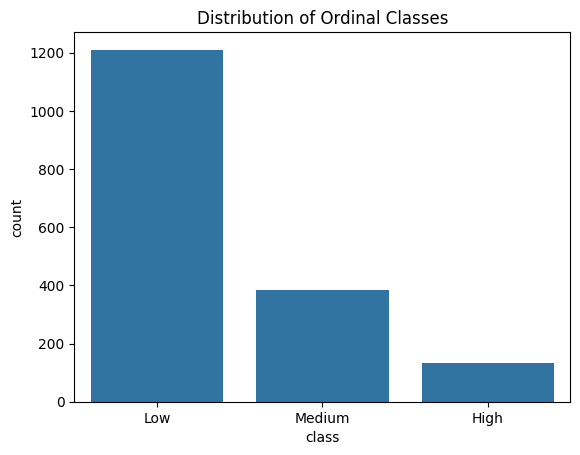

In [4]:
# Visualization Part 1(A) : 1
sns.countplot(x="class", data=df)
plt.title("Distribution of Ordinal Classes")
plt.show()

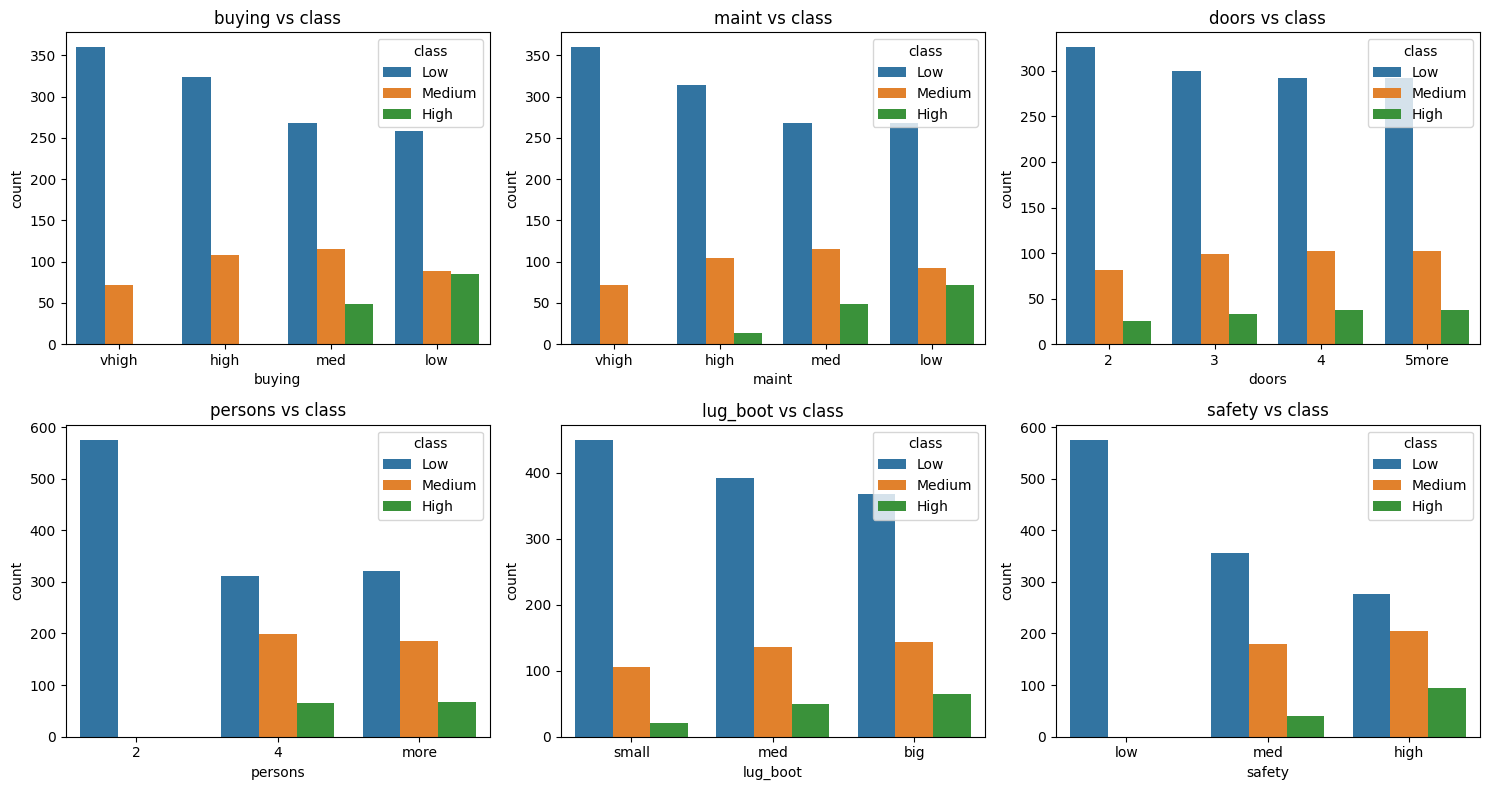

In [5]:
# Visualization Part 1(A) : 2 (Bar Plots)
features = ["buying","maint","doors","persons","lug_boot","safety"]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, feature in enumerate(features):

    sns.countplot(
        x=feature,
        hue="class",
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs class")

plt.tight_layout()
plt.show()

In [6]:
# Part 1(b) : Linear Classifier
# Multi Class Perceptron Algorithm
# (generalizing from batch perceptron discussed in class, to multi class)

X = np.asarray(X)
samples, features = X.shape
classes = 3
weights = np.zeros((features, classes))
bias = np.zeros(classes)
eta = 0.05
epochs = 100

for epoch in range(epochs):
    for i in range(samples):
        scores = np.dot(X[i],weights) + bias
        prediction = np.argmax(scores) + 1
        target = y[i]

        if(prediction != target):
            weights[:,target-1] += eta* X[i]
            weights[:,prediction-1] -= eta* X[i]
            bias[target-1] += eta
            bias[prediction-1] -= eta

df['predicted'] = np.argmax(np.dot(X, weights)+bias,axis = 1) + 1
df['is_correct'] = (df['label'] == df['predicted'])

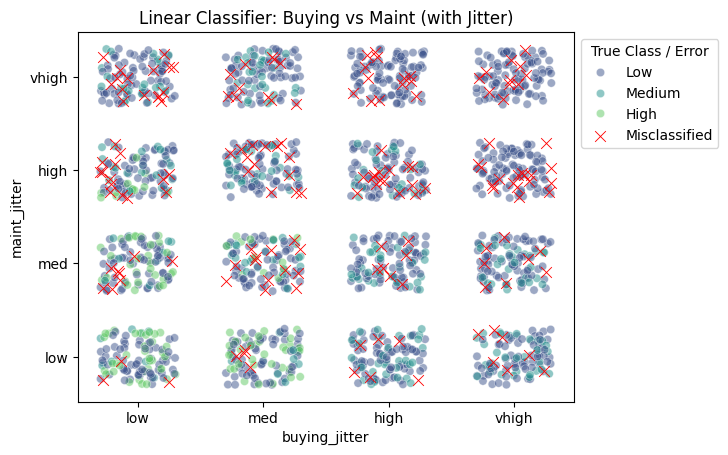

Overall Training Accuracy: 90.2199074074074%


In [7]:
# Visualization and Accuracy of Part 1(B) : Multi Class Perceptron
rank_map = {"low": 1, "med": 2, "high": 3, "vhigh": 4}
df['buying_rank'] = df['buying'].map(rank_map)
df['maint_rank'] = df['maint'].map(rank_map)

df['buying_jitter'] = df['buying_rank'] + np.random.uniform(-0.3, 0.3, len(df))
df['maint_jitter'] = df['maint_rank'] + np.random.uniform(-0.3, 0.3, len(df))

sns.scatterplot(data=df[df['is_correct']], x='buying_jitter', y='maint_jitter', hue='class', palette='viridis', alpha=0.5, marker='o')
sns.scatterplot(data=df[~df['is_correct']], x='buying_jitter', y='maint_jitter', color='red', marker='x', s=60, label='Misclassified')

plt.title("Linear Classifier: Buying vs Maint (with Jitter)")
plt.xticks([1, 2, 3, 4], ['low', 'med', 'high', 'vhigh'])
plt.yticks([1, 2, 3, 4], ['low', 'med', 'high', 'vhigh'])
plt.legend(title="True Class / Error", bbox_to_anchor=(1, 1))
plt.show()

accuracy = df['is_correct'].mean() * 100
print(f"Overall Training Accuracy: {accuracy}%")

Training binary classifier for Class 1...
Training binary classifier for Class 2...
Training binary classifier for Class 3...


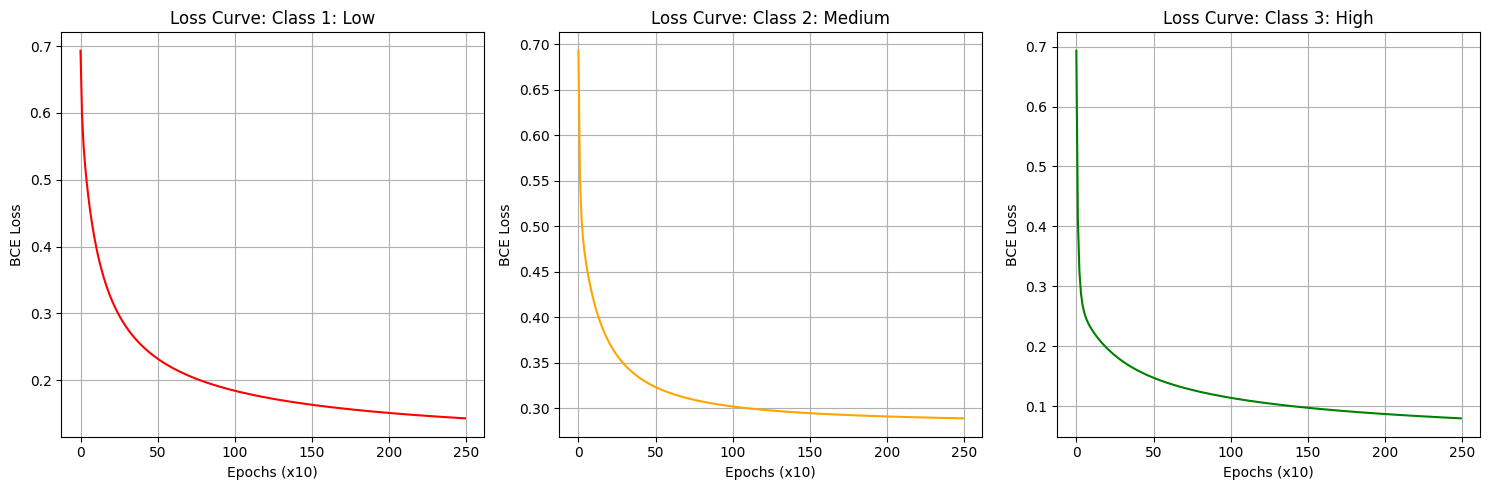

Training Accuracy: 89.4356005788712%
Testing Accuracy:  88.72832369942196%


<Figure size 800x600 with 0 Axes>

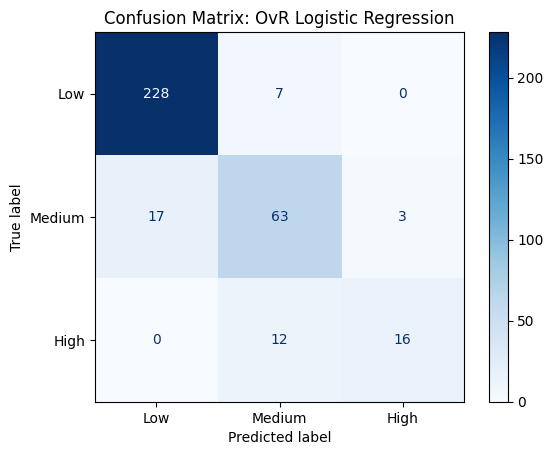

In [8]:
# Task 2 : One-vs-Rest Logistic Regression

class LogisticRegression:
    def __init__(self, alpha=0.1, epochs=2000):
        self.alpha = alpha
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def binary_cross_entropy(self, y, y_hat):
        epsilon = 1e-15
        return -np.mean(y *np.log(y_hat + epsilon) + (1-y) * np.log(1-y_hat + epsilon))

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.loss = []

        for epoch in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_hat = self.sigmoid(z)
            dw = (1/m) * np.dot(X.T, (y_hat - y))
            db = (1/m) * np.sum(y_hat - y)
            self.weights -= self.alpha * dw
            self.bias -= self.alpha * db

            if(epoch%10 == 0):
                self.loss.append(self.binary_cross_entropy(y, y_hat))

    def predict(self, X):
        return self.sigmoid(np.dot(X, self.weights) + self.bias)

class OvRClassifier:
    def __init__(self, classes, alpha=0.1, epochs=2000):
        self.alpha = alpha
        self.epochs = epochs
        self.models = {}
        self.classes = [i for i in range(1, classes + 1)]

    def fit(self, X, y):
        for c in self.classes:
            print(f"Training binary classifier for Class {c}...")
            y_c = (y == c).astype(int)
            model = LogisticRegression(alpha=self.alpha, epochs=self.epochs)
            model.fit(X, y_c)
            self.models[c] = model

    def predict(self, X):
        probs = np.zeros((X.shape[0], len(self.classes)))
        for i, c in enumerate(self.classes):
            probs[:, i] = self.models[c].predict(X)
        return np.array([self.classes[idx] for idx in np.argmax(probs, axis=1)])



from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
ovr = OvRClassifier(classes=3, alpha=0.1, epochs=2500)
ovr.fit(X_train, y_train)

plt.figure(figsize=(15, 5))
colors = ['red','orange','green']
labels = ['Class 1: Low', 'Class 2: Medium', 'Class 3: High']

for i, (c, model) in enumerate(ovr.models.items()):
    plt.subplot(1, 3, i+1)
    plt.plot(model.loss, color=colors[i])
    plt.title(f"Loss Curve: {labels[i]}")
    plt.xlabel("Epochs (x10)")
    plt.ylabel("BCE Loss")
    plt.grid(True)

plt.tight_layout()
plt.show()

train_preds = ovr.predict(X_train)
test_preds = ovr.predict(X_test)
train_acc = np.mean(train_preds == y_train)
test_acc = np.mean(test_preds == y_test)

print(f"Training Accuracy: {train_acc*100}%")
print(f"Testing Accuracy:  {test_acc*100}%")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: OvR Logistic Regression")
plt.show()

In [9]:
class Regularized_LogisticRegression:
    def __init__(self, alpha=0.1, epochs=10000, type = None, lam = 0.01):
        self.alpha = alpha
        self.epochs = epochs
        self.type = type
        self.lam = lam
        self.weights = None
        self.bias = None
        self.loss = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def binary_cross_entropy(self, y, y_hat):
        epsilon = 1e-15
        return -np.mean(y *np.log(y_hat + epsilon) + (1-y) * np.log(1-y_hat + epsilon))

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.loss = []

        for epoch in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_hat = self.sigmoid(z)
            dw = (1/m) * np.dot(X.T, (y_hat - y))
            db = (1/m) * np.sum(y_hat - y)
            if(self.type == 'l2'):
                dw += (self.lam * self.weights)
            elif(self.type == 'l1'):
                dw += (self.lam * np.sign(self.weights))
            self.weights -= self.alpha * dw
            self.bias -= self.alpha * db

            if(epoch%10 == 0):
                self.loss.append(self.binary_cross_entropy(y, y_hat))

    def predict(self, X):
        return self.sigmoid(np.dot(X, self.weights) + self.bias)


class Regularized_OvRClassifier:
    def __init__(self, classes, type = None, lam = 0.01):
        self.type = type
        self.lam = lam
        self.models = {}
        self.classes = [i for i in range(1, classes + 1)]

    def fit(self, X, y):
        for c in self.classes:
            print(f"Training binary classifier for Class {c}...")
            y_c = (y == c).astype(int)
            model = Regularized_LogisticRegression(type = self.type, lam = self.lam)
            model.fit(X, y_c)
            self.models[c] = model

    def predict(self, X):
        probs = np.zeros((X.shape[0], len(self.classes)))
        for i, c in enumerate(self.classes):
            probs[:, i] = self.models[c].predict(X)
        return np.array([self.classes[idx] for idx in np.argmax(probs, axis=1)])

ovr_l1 = Regularized_OvRClassifier(classes = 3, type='l1', lam=0.001)
ovr_l1.fit(X_train, y_train)

ovr_l2 = Regularized_OvRClassifier(classes = 3, type='l2', lam=0.001)
ovr_l2.fit(X_train, y_train)

def get_report(model, name):
    train_acc = np.mean(model.predict(X_train) == y_train)
    test_acc = np.mean(model.predict(X_test) == y_test)
    return train_acc, test_acc

res_l1 = get_report(ovr_l1, "L1 (Lasso)")
res_l2 = get_report(ovr_l2, "L2 (Ridge)")


print("L1 (Lasso)", "Training Accuracy: ", res_l1[0], "Test Accuracy: ", res_l1[1])
print("L2 (Ridge)", "Training Accuracy: ", res_l2[0], "Test Accuracy: ", res_l2[1])

Training binary classifier for Class 1...
Training binary classifier for Class 2...
Training binary classifier for Class 3...
Training binary classifier for Class 1...
Training binary classifier for Class 2...
Training binary classifier for Class 3...
L1 (Lasso) Training Accuracy:  0.9131693198263386 Test Accuracy:  0.9017341040462428
L2 (Ridge) Training Accuracy:  0.9015918958031838 Test Accuracy:  0.8930635838150289


In [10]:
# Part 4 : Ordinal Logistic Regression : Architechture

# Ordinal Logistic Regression Class for 3 Classes
class OrdinalLogisticRegression:
    def __init__(self, alpha=0.001, epochs=1000):
        self.alpha = alpha
        self.epochs = epochs
        self.weights = None
        # this is 21 dimension weight vector
        self.theta = None
        # this is a 2 dimensional threshold vector, theta_1 and theta_2

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        N, M = X.shape
        self.weights = np.zeros(M)
        # M = 21
        self.theta = np.array([-1.0, 1.0])

        y1 = (y==1).astype(int)
        y2 = (y==2).astype(int)
        y3 = (y==3).astype(int)

        eps = 1e-15

        # for the gradients and the mathematics involved, please refer to the report
        for i in range(self.epochs):
            phi1 = np.clip(self.sigmoid(self.theta[0] - X@self.weights), eps, 1-eps)
            phi2 = np.clip(self.sigmoid(self.theta[1] - X@self.weights), eps, 1-eps)
            p_y2 = np.clip(phi2 - phi1, eps, 1 - eps)
            p_y3 = np.clip(1 - phi2, eps, 1 - eps)
            dphi1 = phi1 * (1-phi1)
            dphi2 = phi2 * (1-phi2)

            term1 = (y1 / phi1)[:, None] * (-dphi1[:, None] * X)
            term2 = (y2 / p_y2)[:, None] * ((-dphi2[:, None] * X) - (-dphi1[:, None] * X))
            term3 = (y3 / p_y3)[:, None] * (dphi2[:, None] * X)
            dw = -np.sum(term1 + term2 + term3, axis=0)

            dtheta1 = -np.sum((y1 / phi1) * dphi1 - (y2 / p_y2) * dphi1)
            dtheta2 = -np.sum((y2 / p_y2) * dphi2 - (y3 / p_y3) * dphi2)

            self.weights -= (self.alpha*dw)
            self.theta[0] -= (self.alpha*dtheta1)
            self.theta[1] -= (self.alpha*dtheta2)

        # just the safety check, most probably won't go in this in condition
            if self.theta[0] >= self.theta[1]:
                self.theta[1] = self.theta[0] + 1e-3

    def predict(self, X):
        # predicting using the learned weights and thresholds
        phi1 = self.sigmoid(self.theta[0] - X @ self.weights)
        phi2 = self.sigmoid(self.theta[1] - X @ self.weights)

        p1 = phi1
        p2 = phi2 - phi1
        p3 = 1 - phi2

        probas = np.column_stack([p1, p2, p3])

        return np.argmax(probas, axis=1) + 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

ordinal_model = OrdinalLogisticRegression(alpha = 0.001,epochs = 4000)
ordinal_model.fit(X_train, y_train)

train_predictions = ordinal_model.predict(X_train)
test_predictions = ordinal_model.predict(X_test)


Ordinal Logistic Regression Results
Train Accuracy: 0.9392185238784371
Test Accuracy : 0.9479768786127167
Train MAE: 0.060781476121562955
Test MAE : 0.05202312138728324


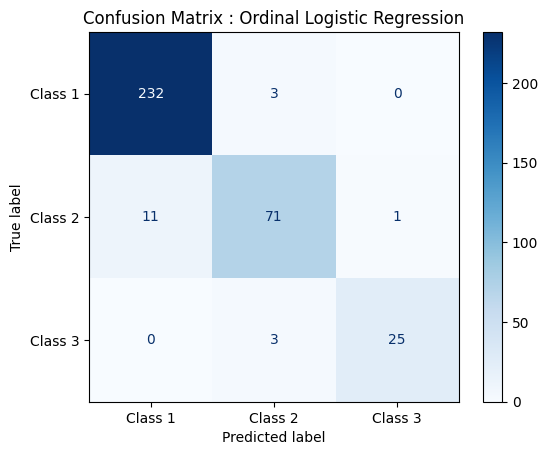


Classification Report
              precision    recall  f1-score   support

           1       0.95      0.99      0.97       235
           2       0.92      0.86      0.89        83
           3       0.96      0.89      0.93        28

    accuracy                           0.95       346
   macro avg       0.95      0.91      0.93       346
weighted avg       0.95      0.95      0.95       346


Extreme Errors (Low ↔ High): 0

Learned Weights: 
[ -3.51819579   2.73591925   0.87821341  -5.28513452  -2.51434683
   1.92324861   0.89000051  -5.48809995  -2.75681033  -1.23494822
  -0.6469266   -0.55051251 -12.29781868   3.6634512    3.44516983
   0.12399096  -1.20768556  -4.10550306   4.85968202 -11.68247163
   1.63359196]

Learned Thresholds
Theta1: -1.1498241539038394
Theta2: 6.3390218081967795


In [11]:
# Part 4 : Ordinal Logistic Regression : Metrics

from sklearn.metrics import accuracy_score, mean_absolute_error, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Ordinal Logistic Regression Results")
print("Train Accuracy:", train_accuracy)
print("Test Accuracy :", test_accuracy)

# Mean Absolute Error
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Train MAE:", train_mae)
print("Test MAE :", test_mae)

# Confusion Matrix
cm = confusion_matrix(y_test, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ["Class 1", "Class 2", "Class 3"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix : Ordinal Logistic Regression")
plt.show()

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, test_predictions))

# Extreme Error Analysis
extreme_errors = np.sum(np.abs(test_predictions - y_test) == 2)
print("\nExtreme Errors (Low ↔ High):", extreme_errors)

# Learned Parameters
print("\nLearned Weights: ")
print(ordinal_model.weights)
print("\nLearned Thresholds")
print("Theta1:", ordinal_model.theta[0])
print("Theta2:", ordinal_model.theta[1])

C:\Users\Arjun Aggarwal\AppData\Local\Temp\ipykernel_11284\2050603589.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=accuracy_df, x='Dataset', y='Accuracy', palette="viridis", ax=ax1)
C:\Users\Arjun Aggarwal\AppData\Local\Temp\ipykernel_11284\2050603589.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mae_df, x='Dataset', y='MAE', palette="magma", ax=ax2)
C:\Users\Arjun Aggarwal\AppData\Local\Temp\ipykernel_11284\2050603589.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weight_df, x='Weight', y='Feature',palett

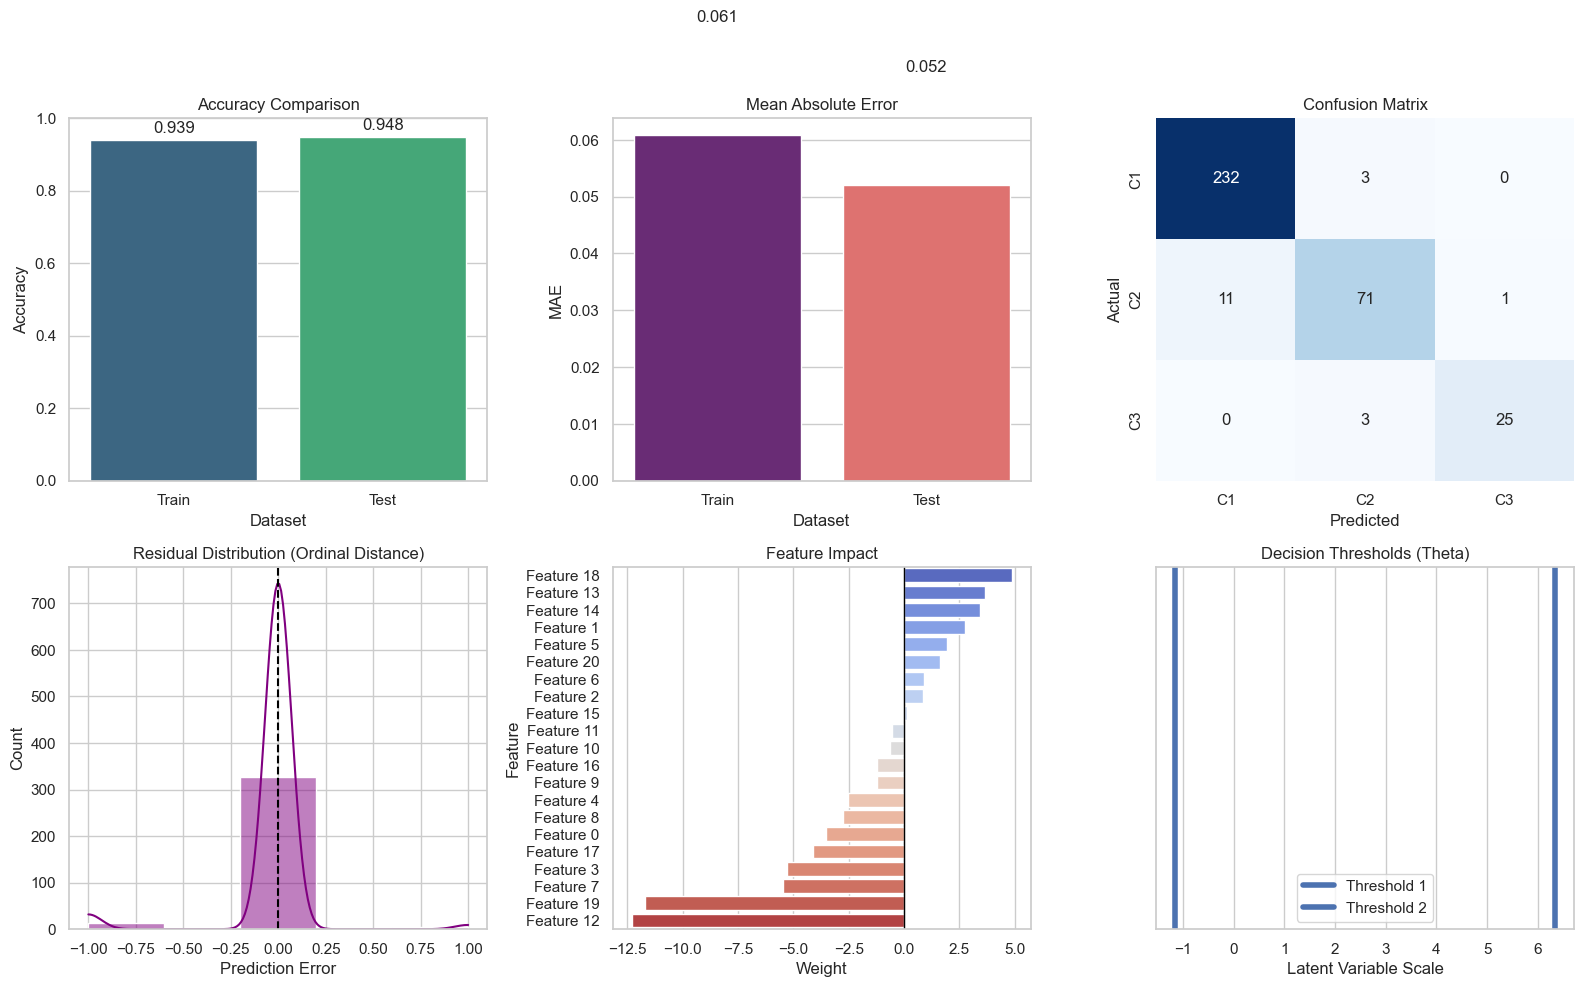

In [12]:
# Part 4 : Ordinal Logistic Regression : Visualization

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

ax1 = fig.add_subplot(gs[0, 0])
accuracy_df = pd.DataFrame({'Dataset': ['Train', 'Test'],'Accuracy': [train_accuracy, test_accuracy]})
sns.barplot(data=accuracy_df, x='Dataset', y='Accuracy', palette="viridis", ax=ax1)
ax1.set_ylim(0, 1)
ax1.set_title("Accuracy Comparison")
for i, v in enumerate(accuracy_df['Accuracy']):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha='center')

ax2 = fig.add_subplot(gs[0, 1])
mae_df = pd.DataFrame({'Dataset': ['Train', 'Test'],'MAE': [train_mae, test_mae]})
sns.barplot(data=mae_df, x='Dataset', y='MAE', palette="magma", ax=ax2)
ax2.set_title("Mean Absolute Error")
for i, v in enumerate(mae_df['MAE']):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center')

ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, test_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=["C1", "C2", "C3"], yticklabels=["C1", "C2", "C3"], ax=ax3)
ax3.set_title("Confusion Matrix")
ax3.set_xlabel("Predicted")
ax3.set_ylabel("Actual")

ax4 = fig.add_subplot(gs[1, 0])
residuals = test_predictions - y_test
sns.histplot(residuals, bins=5, kde=True, color="purple", ax=ax4)
ax4.axvline(0, color='black', linestyle='--')
ax4.set_title("Residual Distribution (Ordinal Distance)")
ax4.set_xlabel("Prediction Error")

ax5 = fig.add_subplot(gs[1, 1])
weights = ordinal_model.weights.flatten()
if hasattr(X_train, 'columns'):
    feat_names = X_train.columns
else:
    feat_names = [f"Feature {i}" for i in range(len(weights))]
weight_df = pd.DataFrame({'Weight': weights, 'Feature': feat_names})
weight_df = weight_df.sort_values(by='Weight', ascending=False)
sns.barplot(data=weight_df, x='Weight', y='Feature',palette="coolwarm", ax=ax5)
ax5.axvline(0, color='black', lw=1)
ax5.set_title("Feature Impact")

ax6 = fig.add_subplot(gs[1, 2])
for i, theta in enumerate(ordinal_model.theta):
    ax6.axvline(theta, label=f'Threshold {i+1}', lw=4)
ax6.set_yticks([])
ax6.set_title("Decision Thresholds (Theta)")
ax6.legend()
ax6.set_xlabel("Latent Variable Scale")

plt.tight_layout()
plt.show()

# Task 2: Decision Trees Classification (35 Marks)

The Iris dataset consists of 150 instances belonging to three flower species, each represented by four numerical attributes. The dataset can be directly accessed using sklearn.datasets, making it suitable for controlled experimentation. In this assignment, you will examine how splitting criteria, model complexity, and data partitioning strategies affect the performance and stability of a Decision Tree classifier.

**Note:** You are NOT allowed to use the inbuilt Decision Tree implementation from sklearn. The classifier must be implemented from scratch.

### 1. **Dataset Understanding (2 Marks)**
    
 Load the Iris dataset using appropriate tools from sklearn. Report the dimensionality of the dataset, the feature names, and the class labels. Using a random seed value of 42, split the dataset into training and test subsets with an 80:20 ratio. Display a small representative subset of both the splits.

### 2.  **Training the decision tree (7+3+2+2 = 14 Marks)**
    
  a.) Train a Decision Tree classifier with **Entropy** as the splitting criterion.

  b.) Visualize the learned tree, clearly indicating the feature splits and predicted class labels.

  c.) Report the depth of the tree and the number of leaf nodes, and briefly comment on the interpretability of the resulting model.

  d.) Evaluate the trained classifier using accuracy, precision, recall, and F1-score, and present the corresponding confusion matrix. Analyze and comment on the class-wise performance.

### 3. **Entropy vs Gini Index (4+2 = 6 Marks)**
    
   Next, investigate the effect of the splitting criterion.
   
   a.) Train another Decision Tree model using the **Gini index**, while keeping all other parameters unchanged.
   
   b.) Compare the resulting trees in terms of structural complexity and classification performance, and discuss any notable differences.

### 4. **Role of Max Depth (4+1 = 5 Marks)**

  a.) To study the role of model complexity, vary the maximum depth of the tree over a reasonable range (You can use three different depth values) and analyze its impact on training and test performance.

  b.) Identify a depth that offers a suitable trade-off between underfitting and overfitting, and justify your choice based on the observed results.

<!-- ### 5. **Role of Data Partitioning (4+1 = 5 Marks)**

  a.) Finally, assess the robustness of the Decision Tree classifier by training three different random seed values {42, 3, 30} for the train–test split. (Use any splitting criterion and keep other parameters constant)
  
  b.) Compare the evaluation metrics obtained across these runs and comment on the stability of the model with respect to data partitioning. -->


### 5. **Random Forest Classifier (5+2+1 = 8 Marks)**

Decision Trees are known to be high-variance models and can be sensitive to the specific training data. Ensemble methods such as Random Forests address this limitation through bootstrap aggregation (bagging) and random feature selection.

a.)Train a Random Forest classifier on the Iris dataset using a fixed number of trees (Use num_trees = 5). Ensure that each tree is trained on a bootstrap sample of the training data, while keeping the train–test split and evaluation protocol identical to the earlier experiments.

b.) Compare the performance of the Random Forest classifier with that of a single Decision Tree in terms of accuracy, precision, recall, F1-score, and confusion matrix. Comment on any improvements or changes observed.

c.) Using the obtained results, explain how bagging helps reduce variance and improves model stability. In your discussion, relate the ensemble behavior of Random Forests to the sensitivity of individual Decision Trees observed in earlier sections of the assignment.
  


In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

df_iris = load_iris()

X = df_iris.data
y = df_iris.target

feature_names = df_iris.feature_names
class_labels = df_iris.target_names

print("Dimensionality of the dataset is", X.shape)
print("Feature Names are : ", feature_names)
print("Class Labels are : ", class_labels)

# i have used stratify for avoiding uneven distributions
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

train_df = pd.DataFrame(X_train, columns=feature_names)
train_df["class"] = y_train
print("A small representative set of training set: ")
print(train_df.head())
print(train_df.shape)


test_df = pd.DataFrame(X_test, columns=feature_names)
test_df["class"] = y_test
print("A small representative set of test set: ")
print(test_df.head())
print(test_df.shape)


Dimensionality of the dataset is (150, 4)
Feature Names are :  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class Labels are :  ['setosa' 'versicolor' 'virginica']
A small representative set of training set: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                4.4               2.9                1.4               0.2   
1                4.9               2.5                4.5               1.7   
2                6.8               2.8                4.8               1.4   
3                4.9               3.1                1.5               0.1   
4                5.5               2.5                4.0               1.3   

   class  
0      0  
1      2  
2      1  
3      0  
4      1  
(120, 5)
A small representative set of test set: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                4.4               3.0                1.3               0.2   
1   

In [14]:
# Task 2 :
'''
Train a Decision Tree classifier with Entropy as the splitting criterion.
'''
class DecisionTreeClassifier_Entropy:
    class Node:
        def __init__(self, is_leaf=False, prediction=None, samples=None, feature=None, threshold=None, left=None, right=None):
            self.is_leaf = is_leaf
            self.prediction = prediction
            self.samples = samples
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right

    # introducing 'maximum depth' of tree and 'minimum samples for splitting' as hyperparameters
    def __init__(self, max_depth=None, min_samples_split = 2):
        self.max_depth = max_depth
        self.min_samples_split = max(min_samples_split, 2)
        self.root = None
        self.feature_names = None
        self.class_names = None

    @staticmethod
    def entropy(x):
        # x is a 1-d array of the class labels for a particular node
        if(len(x) == 0):
            return 0
        values, counts = np.unique(x, return_counts = True)
        probs = counts/ len(x)
        return float(-np.sum([p*np.log2(p) for p in probs if p>0]))

    def majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    # (helps to find the best split using the maximumm information gain (entropy criterion))
    def best_split(self, X, y):
        # parent entropy is the entropy refers to node we are splitting on 
        parent_entropy = self.entropy(y)
        nf = X.shape[1]
        # here nf is the number of features which in case of iris dataset is 4
        best_gain = 0
        best_feature = None
        best_threshold = None

        for j in range(nf):
            values = np.unique(X[:,j])
            # values.shape[0] = 1 implies that all values are same with respect to that feature
            if(values.shape[0] == 1):
                continue
            thresholds = []
            # getting midpoints as candidate thresholds
            for i in range(1,len(values)):
                thresholds.append((values[i] + values[i-1])/(2.0))
            for threshold in thresholds:
                # left_node and right_node give us 'n' True/False (or) 1/0
                left_node = (X[:,j] <= threshold)
                right_node = (X[:,j] > threshold)
                if(left_node.sum() == 0 or right_node.sum() == 0):
                    continue
                left_entropy = self.entropy(y[left_node])
                right_entropy = self.entropy(y[right_node])
                n = len(y)
                # Weighted Child Entropy
                weighted_child_entropy = ((left_node.sum() / n)*(left_entropy) + (right_node.sum() / n)*(right_entropy))
                information_gain = parent_entropy - weighted_child_entropy
                if(information_gain > best_gain):
                    # do 1e-12 or not? -> decide later
                    best_gain = float(information_gain)
                    best_feature = j
                    best_threshold = float(threshold)
        return best_feature,best_threshold,best_gain

    def build_tree(self, X, y, depth=0):
        node_samples = len(y)
        if(node_samples == 0):
            return None

        # if all samples belong to the same class, then make it a leaf
        if(np.all(y == y[0])):
            return DecisionTreeClassifier_Entropy.Node(is_leaf=True, prediction = int(y[0]), samples = node_samples)

        # if the number of samples is less than minimum number of samples to split on, then make a leaf
        if(node_samples < self.min_samples_split):
            return DecisionTreeClassifier_Entropy.Node(is_leaf=True, prediction = int(self.majority_class(y)), samples= node_samples)

        # if the deoth is greater than equal to maximum depth hyperparameter
        if (self.max_depth is not None) and (depth >= self.max_depth):
            return DecisionTreeClassifier_Entropy.Node(is_leaf=True, prediction=int(self.majority_class(y)), samples=node_samples)

        feature, threshold,gain = self.best_split(X, y)
        # take the feature and threshold upon which the split gives maximum informatio gain
        if feature is None or gain <= 0:
            # cannot split further 
            return DecisionTreeClassifier_Entropy.Node(is_leaf=True, prediction=int(self.majority_class(y)), samples=node_samples)

        left_node = X[:,feature] <= threshold
        right_node = X[:, feature] > threshold
        left_node = self.build_tree(X[left_node], y[left_node], depth+1)
        right_node = self.build_tree(X[right_node], y[right_node], depth+1)
        return DecisionTreeClassifier_Entropy.Node(is_leaf = False, prediction = None, samples = node_samples, feature = feature, threshold = threshold,left = left_node, right = right_node)

    def fit(self, X, y, feature_names=None, class_names=None):
        self.feature_names = feature_names if feature_names is not None else [f"X{i}" for i in range(X.shape[1])]
        self.class_names = class_names if class_names is not None else [str(i) for i in np.unique(y)]
        self.root = self.build_tree(np.array(X), np.array(y), depth=0)
        return self

    def predict_single(self, x, node):
        if(node.is_leaf):
            # if node is a leaf, return the prediction of that leaf node
            return node.prediction
        if(x[node.feature] <= node.threshold):
            # feature value (best_feature for the splitting node) is less than best_threshold of the splitting node
            return self.predict_single(x, node.left)
        else:
            # greater than
            return self.predict_single(x, node.right)

    def predict(self, X):
        X = np.array(X)
        preds = [self.predict_single(x, self.root) for x in X]
        return np.array(preds, dtype = int)

    def tree_text(self, node=None, depth=0):
        if node is None:
            node = self.root
        indent = "  " * depth
        if node.is_leaf:
            label = self.class_names[node.prediction] if self.class_names is not None else str(node.prediction)
            return f"{indent}Leaf: predict {label} (samples={node.samples})\n"
        feat_name = self.feature_names[node.feature] if self.feature_names is not None else f"X{node.feature}"
        s = f"{indent}Node: if {feat_name} <= {node.threshold:.4f} (samples={node.samples})\n"
        s += self.tree_text(node.left, depth + 1)
        s += self.tree_text(node.right, depth + 1)
        return s

    def count_leaves(self, node=None):
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return self.count_leaves(node.left) + self.count_leaves(node.right)

    def depth(self, node=None):
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return 1 + max(self.depth(node.left), self.depth(node.right))


Model Results
Train Accuracy:  100.00%
Test Accuracy:   93.33%
Tree Depth:      6
Leaf Nodes:      8
Tree Structure:
Node: if petal length (cm) <= 2.4500 (samples=120)
  Leaf: predict setosa (samples=40)
  Node: if petal width (cm) <= 1.6500 (samples=80)
    Node: if petal length (cm) <= 4.9500 (samples=42)
      Leaf: predict versicolor (samples=38)
      Node: if sepal length (cm) <= 6.1500 (samples=4)
        Node: if sepal width (cm) <= 2.4500 (samples=2)
          Leaf: predict virginica (samples=1)
          Leaf: predict versicolor (samples=1)
        Leaf: predict virginica (samples=2)
    Node: if petal length (cm) <= 4.8500 (samples=38)
      Node: if sepal width (cm) <= 3.0000 (samples=3)
        Leaf: predict virginica (samples=2)
        Leaf: predict versicolor (samples=1)
      Leaf: predict virginica (samples=35)


Evaluation Metrics (Test Set)

Class: setosa
Precision: 1.000
Recall:    1.000
F1 Score:  1.000

Class: versicolor
Precision: 0.900
Recall:    0.900
F1 Score

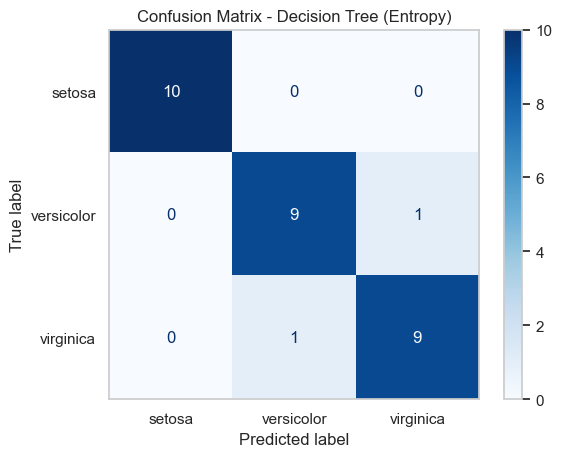

In [15]:
# Now training on iris dataset for entropy criterion
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
tree = DecisionTreeClassifier_Entropy(max_depth=None, min_samples_split=2)
tree.fit(X_train, y_train, feature_names=feature_names, class_names=class_labels)

train_predictions = tree.predict(X_train)
test_predictions = tree.predict(X_test)
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

_results = {
    "Accuracy on Training Dataset": train_accuracy,
    "Accuracy on Testing Dataset": test_accuracy,
    "Depth": tree.depth(),
    "Leaf_nodes": tree.count_leaves(),
    "Tree": tree.tree_text()
}

print(f"{'Model Results':}")
print(f"Train Accuracy:  {_results['Accuracy on Training Dataset']:.2%}")
print(f"Test Accuracy:   {_results['Accuracy on Testing Dataset']:.2%}")
print(f"Tree Depth:      {_results['Depth']}")
print(f"Leaf Nodes:      {_results['Leaf_nodes']}")
print("Tree Structure:")
print(_results['Tree'])

# Tree Metrics (Trained Using Entropy Criteria)
precision = precision_score(y_test, test_predictions, average=None)
recall = recall_score(y_test, test_predictions, average=None)
f1 = f1_score(y_test, test_predictions, average=None)
print("\nEvaluation Metrics (Test Set)")
for i, label in enumerate(class_labels):
    print(f"\nClass: {label}")
    print(f"Precision: {precision[i]:.3f}")
    print(f"Recall:    {recall[i]:.3f}")
    print(f"F1 Score:  {f1[i]:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, test_predictions, target_names=class_labels))
cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")
plt.grid(False)
plt.title("Confusion Matrix - Decision Tree (Entropy)")
plt.show()

# Note : Outpit is getting truncated, to view everything use scrollable element

In [17]:
# Task 3 :
'''
Train another Decision Tree model using the Gini index, while keeping all other parameters unchanged.
'''
class DecisionTreeClassifier_Gini:
    class Node:
        def __init__(self, is_leaf=False, prediction=None, samples=None, feature=None, threshold=None, left=None, right=None):
            self.is_leaf = is_leaf
            self.prediction = prediction
            self.samples = samples
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right

    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = max(min_samples_split, 2)
        self.root = None
        self.feature_names = None
        self.class_names = None

    @staticmethod
    def gini(x):
        if(len(x) == 0):
            return 0.0
        values, counts = np.unique(x, return_counts=True)
        probs = counts / len(x)
        return float(1.0 - np.sum(probs ** 2))

    def majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def best_split(self, X, y):
        parent_gini = self.gini(y)
        nf = X.shape[1]
        best_decrease = 0.0
        best_feature = None
        best_threshold = None

        for j in range(nf):
            values = np.unique(X[:, j])
            if values.shape[0] == 1:
                continue
            thresholds = [(values[i] + values[i-1]) / 2.0 for i in range(1,len(values))]
            for threshold in thresholds:
                left_node = (X[:, j] <= threshold)
                right_node = (X[:, j] > threshold)
                n_left = left_node.sum()
                n_right = right_node.sum()
                if(n_left == 0 or n_right == 0):
                    continue
                left_gini = self.gini(y[left_node])
                right_gini = self.gini(y[right_node])
                n = len(y)
                weighted_child_gini = ((n_left/n)*left_gini) + ((n_right/n)*right_gini)
                gini_decrease = parent_gini - weighted_child_gini
                if(gini_decrease > best_decrease):
                    best_decrease = float(gini_decrease)
                    best_feature = j
                    best_threshold = float(threshold)
        return best_feature, best_threshold, best_decrease

    def build_tree(self, X, y, depth=0):
        node_samples = len(y)
        if(node_samples == 0):
            return None
        if(np.all(y == y[0])):
            return DecisionTreeClassifier_Gini.Node(is_leaf=True, prediction=int(y[0]), samples=node_samples)
        if(node_samples < self.min_samples_split):
            return DecisionTreeClassifier_Gini.Node(is_leaf=True, prediction=int(self.majority_class(y)), samples=node_samples)
        if((self.max_depth is not None) and (depth >= self.max_depth)):
            return DecisionTreeClassifier_Gini.Node(is_leaf=True, prediction=int(self.majority_class(y)), samples=node_samples)

        feature, threshold, decrease = self.best_split(X, y)
        if(feature is None or decrease <= 0):
            return DecisionTreeClassifier_Gini.Node(is_leaf=True, prediction=int(self.majority_class(y)), samples=node_samples)

        left_mask = (X[:, feature] <= threshold)
        right_mask = (X[:, feature] > threshold)
        left_node = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_node = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        return DecisionTreeClassifier_Gini.Node(is_leaf=False, prediction=None, samples=node_samples,feature=feature, threshold=threshold, left=left_node, right=right_node)

    def fit(self, X, y, feature_names=None, class_names=None):
        self.feature_names = feature_names if feature_names is not None else [f"X{i}" for i in range(X.shape[1])]
        self.class_names = class_names if class_names is not None else [str(i) for i in np.unique(y)]
        self.root = self.build_tree(np.array(X), np.array(y), depth=0)
        return self

    def predict_single(self, x, node):
        if(node.is_leaf):
            return node.prediction
        if(x[node.feature] <= node.threshold):
            return self.predict_single(x, node.left)
        else:
            return self.predict_single(x, node.right)

    def predict(self, X):
        X = np.array(X)
        preds = [self.predict_single(x, self.root) for x in X]
        return np.array(preds, dtype=int)

    def tree_text(self, node=None, depth=0):
        if(node is None):
            node = self.root
        indent = "  " * depth
        if(node.is_leaf):
            label = self.class_names[node.prediction] if self.class_names is not None else str(node.prediction)
            return f"{indent}Leaf: predict {label} (samples={node.samples})\n"
        feat_name = self.feature_names[node.feature] if self.feature_names is not None else f"X{node.feature}"
        s = f"{indent}Node: if {feat_name} <= {node.threshold:.4f} (samples={node.samples})\n"
        s += self.tree_text(node.left, depth + 1)
        s += self.tree_text(node.right, depth + 1)
        return s

    def count_leaves(self, node=None):
        if(node is None):
            node = self.root
        if(node.is_leaf):
            return 1
        return self.count_leaves(node.left) + self.count_leaves(node.right)

    def depth(self, node=None):
        if(node is None):
            node = self.root
        if(node.is_leaf):
            return 1
        return 1 + max(self.depth(node.left), self.depth(node.right))

Model Results
Train Accuracy:  100.00%
Test Accuracy:   93.33%
Tree Depth:      6
Leaf Nodes:      8
Tree Structure:
Node: if petal length (cm) <= 2.4500 (samples=120)
  Leaf: predict setosa (samples=40)
  Node: if petal width (cm) <= 1.6500 (samples=80)
    Node: if petal length (cm) <= 4.9500 (samples=42)
      Leaf: predict versicolor (samples=38)
      Node: if sepal length (cm) <= 6.1500 (samples=4)
        Node: if sepal width (cm) <= 2.4500 (samples=2)
          Leaf: predict virginica (samples=1)
          Leaf: predict versicolor (samples=1)
        Leaf: predict virginica (samples=2)
    Node: if petal length (cm) <= 4.8500 (samples=38)
      Node: if sepal width (cm) <= 3.0000 (samples=3)
        Leaf: predict virginica (samples=2)
        Leaf: predict versicolor (samples=1)
      Leaf: predict virginica (samples=35)


Evaluation Metrics (Test Set)

Class: setosa
Precision: 1.000
Recall:    1.000
F1 Score:  1.000

Class: versicolor
Precision: 0.900
Recall:    0.900
F1 Score

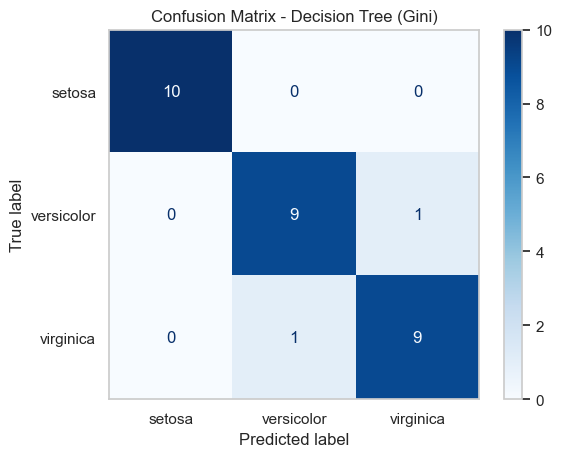

In [18]:
# Now training on iris dataset for gini index criterion
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
tree = DecisionTreeClassifier_Gini(max_depth=None, min_samples_split=2)
tree.fit(X_train, y_train, feature_names=feature_names, class_names=class_labels)

train_predictions = tree.predict(X_train)
test_predictions = tree.predict(X_test)
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

_results = {
    "Accuracy on Training Dataset": train_accuracy,
    "Accuracy on Testing Dataset": test_accuracy,
    "Depth": tree.depth(),
    "Leaf_nodes": tree.count_leaves(),
    "Tree": tree.tree_text()
}

print(f"{'Model Results':}")
print(f"Train Accuracy:  {_results['Accuracy on Training Dataset']:.2%}")
print(f"Test Accuracy:   {_results['Accuracy on Testing Dataset']:.2%}")
print(f"Tree Depth:      {_results['Depth']}")
print(f"Leaf Nodes:      {_results['Leaf_nodes']}")
print("Tree Structure:")
print(_results['Tree'])

# Tree Metrics (Trained Using Entropy Criteria)
precision = precision_score(y_test, test_predictions, average=None)
recall = recall_score(y_test, test_predictions, average=None)
f1 = f1_score(y_test, test_predictions, average=None)
print("\nEvaluation Metrics (Test Set)")
for i, label in enumerate(class_labels):
    print(f"\nClass: {label}")
    print(f"Precision: {precision[i]:.3f}")
    print(f"Recall:    {recall[i]:.3f}")
    print(f"F1 Score:  {f1[i]:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, test_predictions, target_names=class_labels))
cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")
plt.grid(False)
plt.title("Confusion Matrix - Decision Tree (Gini)")
plt.show()

# Note : Outpit is getting truncated, to view everything use scrollable element


Accuracy Table:

   Max Depth  Train Accuracy  Test Accuracy
0          1        0.666667       0.666667
1          2        0.966667       0.933333
2          3        0.983333       0.966667
3          4        0.991667       0.933333
4          5        1.000000       0.933333
5          6        1.000000       0.933333
6          7        1.000000       0.933333
7          8        1.000000       0.933333
8          9        1.000000       0.933333
9         10        1.000000       0.933333


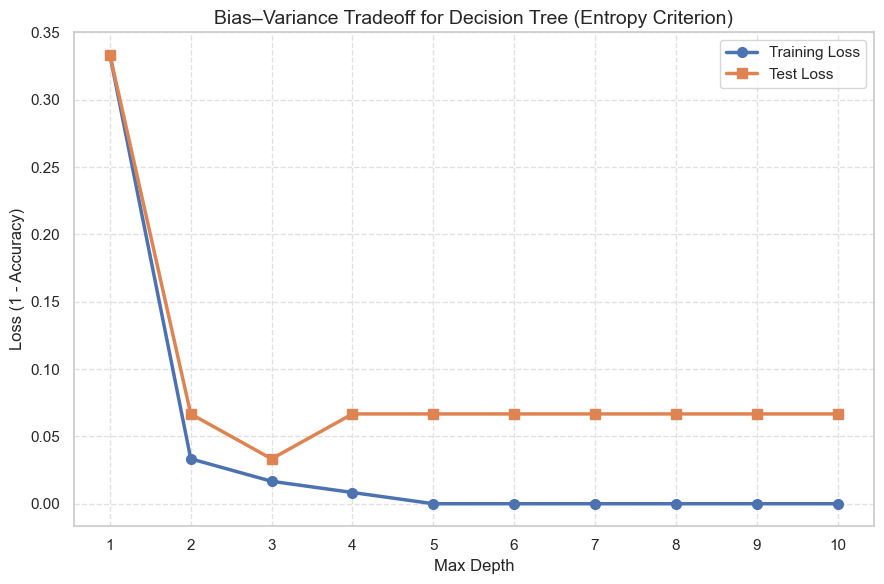

In [20]:
# Task 4 : Role of Max Depth
depth_values = list(range(1, 11))

train_losses = []
test_losses = []
train_accs = []
test_accs = []

for depth in depth_values:

    model = DecisionTreeClassifier_Entropy(max_depth=depth, min_samples_split=2)
    model.fit(X_train, y_train, feature_names=feature_names, class_names=class_labels)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    train_losses.append(1 - train_acc)
    test_losses.append(1 - test_acc)

results_table = pd.DataFrame({
    "Max Depth": depth_values,
    "Train Accuracy": train_accs,
    "Test Accuracy": test_accs
})

print("\nAccuracy Table:\n")
print(results_table)

plt.figure(figsize=(9,6))
plt.plot(depth_values, train_losses,marker='o',linewidth=2.5,markersize=7,label="Training Loss")
plt.plot(depth_values, test_losses,marker='s',linewidth=2.5,markersize=7,label="Test Loss")

plt.xlabel("Max Depth", fontsize=12)
plt.ylabel("Loss (1 - Accuracy)", fontsize=12)
plt.title("Bias–Variance Tradeoff for Decision Tree (Entropy Criterion)", fontsize=14)

plt.xticks(depth_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# Part 5
'''
Train a Random Forest classifier on the Iris dataset using a fixed number of trees (Use num_trees = 5)
'''

# in random forest, we use random feature selection, for eg in my implementation i have take sqrt(n) random features without replacement
# for this i have to modify the functionality of the best_split function of my decision tree classifier i implemented before
# so, i am using class inheritance here, parent class is DecisionTreeClassifier_Entropy and child class is with RandomFeature

class DecisionTreeClassifier_Entropy_RandomFeature(DecisionTreeClassifier_Entropy):
    def __init__(self, max_depth=None, min_samples_split=2, max_features=None, random_state=None):
        # calling the parent constructor using the super() method
        super().__init__(max_depth=max_depth, min_samples_split=min_samples_split)
        # if max_features is none we use all features
        self.max_features = max_features
        self.rng = np.random.RandomState(random_state)

    def best_split(self, X, y):
        parent_entropy = self.entropy(y)
        nf = X.shape[1]
        # determine number of features to try
        # if none, try all features
        if(self.max_features is None):
            m = nf
        else:
            if isinstance(self.max_features, str) and self.max_features == "sqrt":
                m = max(1, int(np.sqrt(nf)))
            else:
                m = int(self.max_features)
                m = max(1, min(nf, m))
        # sampling m features without replacement
        features = self.rng.choice(np.arange(nf), size=m, replace=False)

        # this is now the same code as before after we randomly selected the m features without replacement
        best_gain = 0.0
        best_feature = None
        best_threshold = None

        for j in features:
            values = np.unique(X[:, j])
            if(values.shape[0] == 1):
                continue
            thresholds = [(values[i] + values[i-1]) / 2.0 for i in range(1, len(values))]
            for threshold in thresholds:
                left_mask = (X[:, j] <= threshold)
                right_mask = (X[:, j] > threshold)
                if(left_mask.sum() == 0 or right_mask.sum() == 0):
                    continue
                left_entropy = self.entropy(y[left_mask])
                right_entropy = self.entropy(y[right_mask])
                n = len(y)
                weighted_child_entropy = ((left_mask.sum()/n)*left_entropy + (right_mask.sum()/n)*right_entropy)
                information_gain = parent_entropy - weighted_child_entropy
                if information_gain > best_gain + 1e-12:
                    best_gain = float(information_gain)
                    best_feature = j
                    best_threshold = float(threshold)
        return best_feature, best_threshold, best_gain

# now, have to implement the bagging technique using bootstrap sampling and then using random feature selection as implemented above
class RandomForestClassifier:
    def __init__(self, num_trees=5, max_depth=None, min_samples_split=2, max_features="sqrt", bootstrap=True, random_state=None):
        self.num_trees = num_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.trees = []
        self.rng = np.random.RandomState(random_state)

    def fit(self, X, y, feature_names=None, class_names=None):
        X = np.array(X)
        y = np.array(y)
        n = X.shape[0]
        self.feature_names = feature_names
        self.class_names = class_names
        self.trees = []
        for t in range(self.num_trees):
            # bootstraping sample indices, which is taking n samples for training each decision tree
            idx = self.rng.choice(n, size=n, replace=self.bootstrap)
            X_sample = X[idx]
            y_sample = y[idx]
            # each tree gets a different random_state for diversity
            tree_random_state = self.rng.randint(0, 10**9)
            tree = DecisionTreeClassifier_Entropy_RandomFeature(max_depth=self.max_depth, min_samples_split=self.min_samples_split,
                                                               max_features=self.max_features, random_state=tree_random_state)
            tree.fit(X_sample, y_sample, feature_names=self.feature_names, class_names=self.class_names)
            self.trees.append(tree)
        return self

    def predict(self, X):
        X = np.array(X)
        # collect predictions from all trees (num_trees, n_samples)
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        # majority vote per column (sample)
        n_samples = X.shape[0]
        preds = np.zeros(n_samples, dtype=int)
        for i in range(n_samples):
            counts = np.bincount(all_preds[:, i])
            preds[i] = int(np.argmax(counts))
        return preds


Single Decision Tree
Train Accuracy : 1.0000
Test Accuracy  : 0.9333
Precision      : 0.9333
Recall         : 0.9333
F1 Score       : 0.9333

Random Forest
Train Accuracy : 0.9917
Test Accuracy  : 0.9333
Precision      : 0.9333
Recall         : 0.9333
F1 Score       : 0.9333


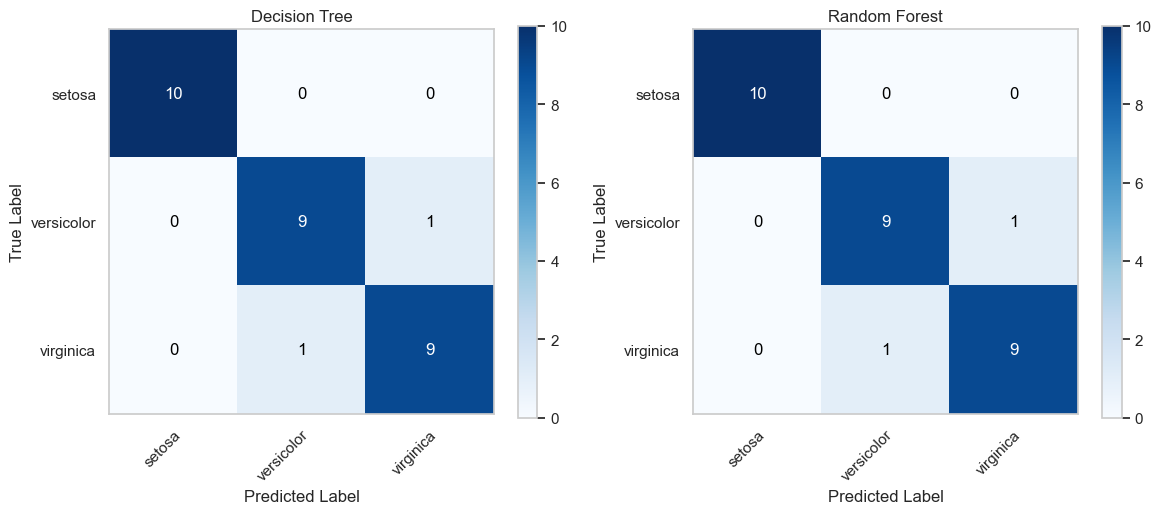

In [22]:
# Now, training on the random forest classifier and comparing it with when trained it on a single tree
data = load_iris()
X = data["data"]
y = data["target"]
feature_names = data["feature_names"]
class_labels = data["target_names"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

single_tree = DecisionTreeClassifier_Entropy(max_depth=None, min_samples_split=2)
single_tree.fit(X_train, y_train, feature_names=feature_names, class_names=class_labels)
single_train = single_tree.predict(X_train)
single_test = single_tree.predict(X_test)

# train random forest with num_trees = 5
rf = RandomForestClassifier(num_trees=5, max_depth=None, min_samples_split=2, max_features="sqrt", bootstrap=True, random_state=42)
rf.fit(X_train, y_train, feature_names=feature_names, class_names=class_labels)
rf_train = rf.predict(X_train)
rf_test = rf.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(name, y_train, train_predictions, y_test, test_predictions):
    print(f"\n{name}")

    train_acc = accuracy_score(y_train, train_predictions)
    test_acc = accuracy_score(y_test, test_predictions)

    precision = precision_score(y_test, test_predictions, average="macro")
    recall = recall_score(y_test, test_predictions, average="macro")

    f1 = f1_score(y_test, test_predictions, average="macro")

    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")

    return confusion_matrix(y_test, test_predictions)


# compute confusion matrices
cm_single = evaluate_model("Single Decision Tree", y_train, single_train, y_test, single_test)
cm_rf = evaluate_model("Random Forest", y_train, rf_train, y_test, rf_test)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, cm, title in zip(axes, [cm_single, cm_rf], ["Decision Tree", "Random Forest"]):

    im = ax.imshow(cm, cmap="Blues")
    ax.grid(False)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

# Task 3 : Support Vector Machine (30 Marks)

Use the same **Iris dataset** with an **80:20 train–test split** (random seed = 42) for this task. It can be observed that some class pairs in the dataset are not perfectly linearly separable, particularly due to overlap between certain classes. Support Vector Machines (SVMs) address this issue by maximizing the margin while allowing controlled misclassification using a soft-margin formulation.

[One-vs-One (OVO)](https://machinelearningmastery.com/one-vs-rest-and-one-vs-one-for-multi-class-classification/) involves creating a binary classifier for every possible pair of classes. For each pair of classes, a binary SVM classifier is trained using only the data points belonging to the two classes being compared. For example, with three classes (A, B, C), classifiers are trained for (A vs B), (A vs C), and (B vs C).


### 1. **OVO Linear SVM Implementation and Hyperparameter Tuning (5 + 3 = 8 Marks)**
a) Implement a **One-vs-One (OVO) Linear SVM** classifier.

b) Perform hyperparameter tuning to identify the optimal penalty parameter **C** using a suitable range of values.

### 2. **Decision Boundary Visualization (4 Marks)**
Using any two features from the dataset (for example, petal length and petal width), plot the decision boundary corresponding to the optimal value of **C**.

### 3. **Analysis of Parameter C in Linear SVM (4 + 3 = 7 Marks)**
a) For different values of **C**, plot the **number of support vectors** and **number of violated points (misclassified points)** on the Y-axis against **C** on the X-axis. Violated points are defined as data points that violate the SVM margin constraint (i.e., points lying inside the margin or misclassified).


b) Discuss how varying **C** affects the **margin width, model complexity and generalization behavior**.

### 4. **Analysis of Kernel SVM (3 + 3 = 6 Marks)**
Linear decision boundaries may not be sufficient when the data exhibits complex structures. [Kernels](https://www.geeksforgeeks.org/machine-learning/major-kernel-functions-in-support-vector-machine-svm/) help by implicitly mapping the original feature space into a higher-dimensional space where the data might be more easily separable.

a) Train non-linear SVM classifiers using **Polynomial kernel** (degree = 2) and **Radial Basis Function (RBF) kernel**. Compare the classifiers in terms of decision boundary smoothness, and number of support vectors.

b) For appropriate values of **C** (Penalty Parameter) and **γ** (Kernel Parameter), do either of the kernels show signs of overfitting? Justify your answer using visualizations and performance metrics.

### 5. **Evaluation Metrics (3 + 2 = 5 Marks)**
a) Evaluate the best-performing SVM model using **Precision, Recall and F1-score**.

b) Report and briefly interpret the results.

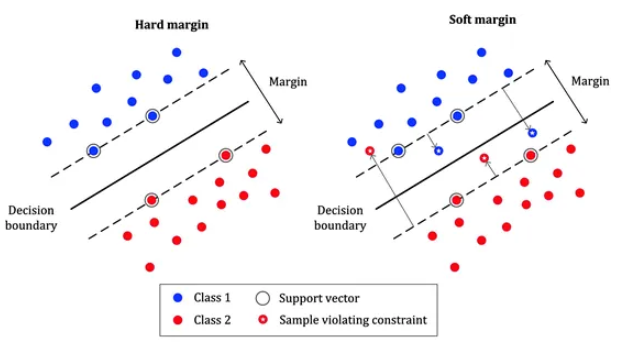



In [27]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
np.random.seed(42)

Starting hyperparameter tuning (5-fold stratified CV) over C values: [0.01, 0.1, 1.0, 10.0, 100.0]
C=0.01    CV mean acc = 0.8667  std = 0.0486
C=0.1     CV mean acc = 0.9750  std = 0.0204
C=1.0     CV mean acc = 0.9750  std = 0.0333
C=10.0    CV mean acc = 0.9500  std = 0.0167
C=100.0   CV mean acc = 0.9667  std = 0.0312

Selected best C based on CV: 0.1
Test accuracy on held-out 20% = 0.9333

Confusion matrix (rows=true, cols=predicted):
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


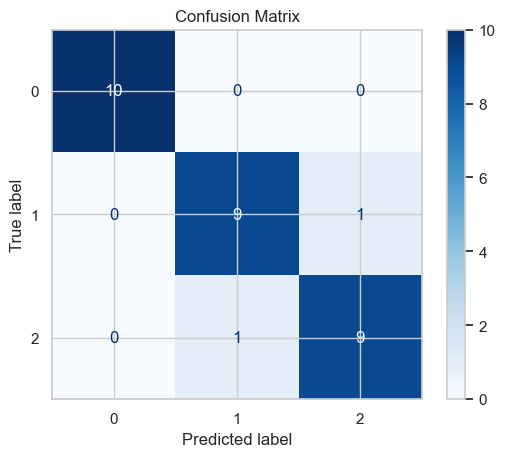


Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [28]:
# Part 1 : OVO Linear SVM Implementation and Hyperparameter Tuning

# this class trains a linear support vector machine by minimizing the hingle loss ( using subgradient descent)
# i looked for the mathematics of the gradient descent for svm from online resources, and have attached the used version in the report also
# i have kept the parameter of my class 'verbose' to be off by default, for training info you can call the model with verbose = True instead
class LinearSVM:
    def __init__(self, C=1.0, alpha=0.01, epochs=2000, random_state=None, verbose=False):
        self.C = float(C)
        self.alpha = float(alpha)
        self.epochs = int(epochs)
        self.random_state = random_state
        self.verbose = verbose
        self.w = None
        self.b = 0.0

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        m, n = X.shape

        # initialize small random weights by normal distribution
        self.w = rng.normal(scale=0.01, size=n)
        self.b = 0.0

        # batch gradient descent (by tweaking the learning rate a little bit as we iterate through learning process)
        for epoch in range(1, self.epochs+1):
            # computing margins
            margins = y * (X.dot(self.w) + self.b)
            # Ref. Class Notes
            # if for sample margins[i] >=1, then it is correctly classified and is outside the boundary
            # if for sample margins[i] < 1, then the hinge loss is active and the point is inside the boundary, so wrong contains 
            # the indices where margins < 1
            wrong = np.where(margins < 1)[0]
            dw = self.w.copy()
            db = 0.0
            if(wrong.size > 0):
                # adding the derivatives of second part (hinge loss derivatives)
                dw += self.C * (-np.dot(y[wrong], X[wrong]))
                db += self.C * (-np.sum(y[wrong]))
            # decyaing the learning rate as epochs proceed
            lr = self.alpha / (1.0 + 0.0001 * epoch)
            # gradient descent
            self.w -= (lr*dw)
            self.b -= (lr*db)

            if self.verbose and (epoch % 500 == 0 or epoch == 1):
                loss = 0.5 * np.dot(self.w, self.w) + self.C * np.sum(np.maximum(0, 1 - margins))
                print(f"Epoch {epoch}/{self.epochs}  loss={loss:.4f}  margin_violations={wrong.size}")

    def decision_function(self, X):
        return X.dot(self.w) + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)


class OVO_LinearSVM:
    # now traning one-vs-one multiclass classifier using the above Linear SVM class
    # for example, if we have 'k' classes, we train k*(k-1)/2 binary Linear SVM classifiers
    # for prediction, each classifier votes for one of the two classes, final predicted class is the majority class

    def __init__(self, C=1.0, alpha=0.01, epochs=2000, random_state=None, verbose=False):
        self.C = C
        self.alpha = alpha
        self.epochs = epochs
        self.random_state = random_state
        self.verbose = verbose
        self.classifiers = {}
    # self.classifiers is a dictionary of keys (tuples : (class i, class j)) and values is the instance of the LinearSVM class trained
    # on the exmaples of these both classes

    def fit(self, X, y):
        labels = np.unique(y)
        # train classifier for every pair of the classes
        # used inbuilt func
        for i in range(len(labels)):
            for j in range(i+1,len(labels)):
                a = labels[i]
                b = labels[j]
                # select only samples of classes a and b
                mask = np.logical_or(y == a, y == b)
                # take only those training examples of classes a and b, and filter them using mask (taught in Lab 0)
                X_pair = X[mask]
                y_pair = y[mask]
                # mapping labels to -1/+1
                y_binary = np.where(y_pair == a, 1, -1)
                svm = LinearSVM(C=self.C, alpha=self.alpha, epochs=self.epochs, random_state=self.random_state, verbose=self.verbose)
                svm.fit(X_pair, y_binary)
                self.classifiers[(a, b)] = svm

    def predict(self, X):
        # for each classifier, get the predicted label (a or b) for X, then majority vote
        m = X.shape[0]
        votes = np.zeros((m,))
        # we will collect votes per class using dictionary of counts per sample
        votes_per_sample = [dict() for _ in range(m)]
        for (a, b), svm in self.classifiers.items():
            preds = svm.predict(X)  # in {-1, +1} where +1 corresponds to class 'a'
            for i, p in enumerate(preds):
                voted_label = a if p == 1 else b
                votes_per_sample[i][voted_label] = votes_per_sample[i].get(voted_label, 0) + 1
        # decide final label per sample: class with highest votes; tie-breaker: smallest label
        final_predictions= np.zeros(m, dtype=int)
        for i, d in enumerate(votes_per_sample):
            # pick label with max votes
            items = list(d.items())
            if not items:
                final_predictions[i] = 0
            else:
                # sort by (-count, label) so highest count and then smallest label wins ties
                items.sort(key=lambda x: (-x[1], x[0]))
                final_predictions[i] = items[0][0]
        return final_predictions

data = load_iris()
X = data["data"]
y = data["target"]
feature_names = data["feature_names"]
class_names = data["target_names"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# rescale the features, important for svm
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# hyperparameter tuning
Cs = [0.01, 0.1, 1.0, 10.0, 100.0]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

# i referred the documentations linked in the report for the hyperparameter tuning using stratified cross validation
print("Starting hyperparameter tuning (5-fold stratified CV) over C values:", Cs)
for C in Cs:
    fold_acc = []
    # for each fold, train OVO on training folds and evaluate on validation fold
    for train_indices, validation_indices in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_indices], X_train[validation_indices]
        y_tr, y_val = y_train[train_indices], y_train[validation_indices]
        # train OVO with current C, and with the given training and validation datasets
        ovo = OVO_LinearSVM(C=C, alpha=0.01, epochs=2000, random_state=42, verbose=False)
        ovo.fit(X_tr, y_tr)
        preds = ovo.predict(X_val)
        acc = accuracy_score(y_val, preds)
        fold_acc.append(acc)
    mean_acc = np.mean(fold_acc)
    std_acc = np.std(fold_acc)
    cv_results[C] = (mean_acc, std_acc)
    print(f"C={C:<6}  CV mean acc = {mean_acc:.4f}  std = {std_acc:.4f}")

# choose best C, using sorted, here lambda function i have used,
# kv[1][0] refers to the mean accuracy for the particular C
# kv[0] refers to the C
# so the sorting criteria is accuracy in decreasing order and if tie, smaller c preferred
C_star = sorted(cv_results.items(), key=lambda kv: (-kv[1][0], kv[0]))[0][0]
print("\nSelected best C based on CV:", C_star)

# train the final model using the best 'C' found using hyperparameter tuning above
ovo = OVO_LinearSVM(C=C_star, alpha=0.01, epochs=5000, random_state=42, verbose=False)
ovo.fit(X_train, y_train)
test_preds = ovo.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print(f"Test accuracy on held-out 20% = {test_acc:.4f}\n")
print("Confusion matrix (rows=true, cols=predicted):")
print(confusion_matrix(y_test, test_preds))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
print("\nClassification report:\n", classification_report(y_test, test_preds, target_names=class_names))


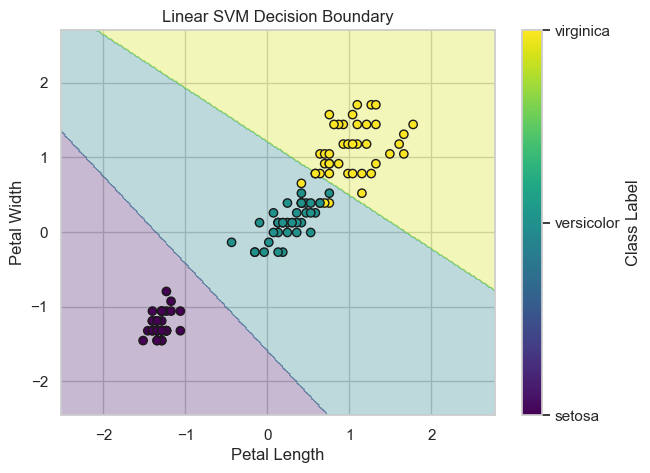

In [29]:
# Part 2 : Decision Boundary Visualization
def plot_decision_boundary(model,X,y,title):

    X2 = X[:,[2,3]]

    x_min,x_max = X2[:,0].min()-1, X2[:,0].max()+1
    y_min,y_max = X2[:,1].min()-1, X2[:,1].max()+1

    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300),np.linspace(y_min,y_max,300))

    grid = np.c_[xx.ravel(),yy.ravel()]

    grid_full = np.zeros((grid.shape[0],X.shape[1]))
    grid_full[:,2] = grid[:,0]
    grid_full[:,3] = grid[:,1]

    Z = model.predict(grid_full)
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(7,5))
    plt.contourf(xx,yy,Z,alpha=0.3,cmap="viridis")
    scatter = plt.scatter(X2[:,0],X2[:,1],c=y,cmap="viridis",edgecolors="k")

    plt.title(title)
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")

    cbar = plt.colorbar(scatter)
    cbar.set_label("Class Label")
    cbar.set_ticks([0,1,2])
    cbar.set_ticklabels(class_names)

    plt.show()

plot_decision_boundary(ovo,X_train,y_train,"Linear SVM Decision Boundary")

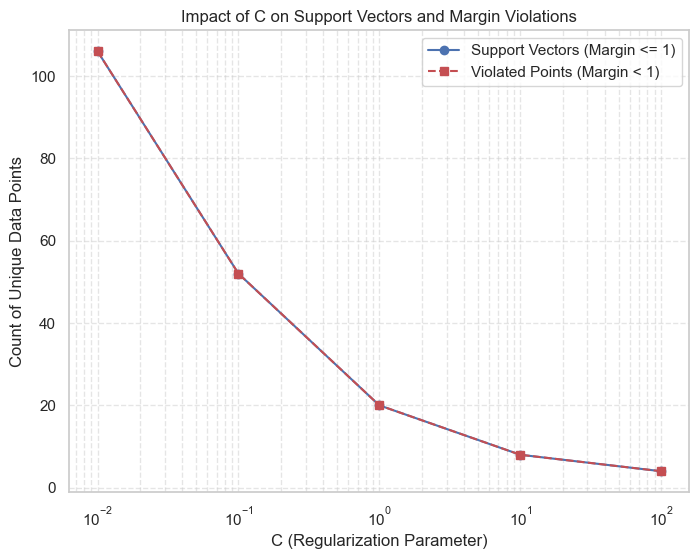

In [31]:
# Part 3
'''
a) For different values of **C**, plot the **number of support vectors** and **number of violated points (misclassified points)** on the Y-axis against **C** on the X-axis
'''
# plotting the number of support vector points and violated points for different values of C
sv_counts = []
violation_counts = []

for C in Cs:
    ovo_model = OVO_LinearSVM(C=C, alpha=0.01, epochs=3000, random_state=42)
    ovo_model.fit(X_train, y_train)

    unique_svs = set()
    unique_violations = set()

    labels = np.unique(y_train)

    # iterating through each binary classifier to find margin violations
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            a = labels[i]
            b = labels[j]

            # Recreate the data mask used for this specific classifier
            mask = np.logical_or(y_train == a, y_train == b)
            X_pair = X_train[mask]
            y_pair = y_train[mask]
            y_binary = np.where(y_pair == a, 1, -1)
            original_indices = np.where(mask)[0]
            svm = ovo_model.classifiers[(a, b)]

            margins = y_binary * (X_pair.dot(svm.w) + svm.b)

            # using some precision, number of support vectors and counting the margin violations
            # margin violation if margins < 1 and support vector if margins <=1
            sv_indices = np.where(margins <= 1.00001)[0]
            violation_indices = np.where(margins < 0.99999)[0]

            unique_svs.update(original_indices[sv_indices])
            unique_violations.update(original_indices[violation_indices])

    sv_counts.append(len(unique_svs))
    violation_counts.append(len(unique_violations))

# Plotting the results
plt.figure(figsize=(8, 6))
plt.plot(Cs, sv_counts, marker='o', linestyle='-', color='b', label='Support Vectors (Margin <= 1)')
plt.plot(Cs, violation_counts, marker='s', linestyle='--', color='r', label='Violated Points (Margin < 1)')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Count of Unique Data Points')
plt.title('Impact of C on Support Vectors and Margin Violations')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()
# analysis on affect of C on margin width, model complexity and generalization behavior is done in the report

In [32]:
# Task 4 : Polynomial and Kernel SVM with OVO SVM
class KernelSVM:
    def __init__(self, C=1.0, kernel="rbf", degree=2, gamma=1.0, epochs=1000, lr=0.001):
        self.C = C
        self.kernel = kernel
        self.degree = degree
        self.gamma = gamma
        self.epochs = epochs
        self.lr = lr

        self.alpha = None
        self.support_vectors = None
        self.support_labels = None
        self.b = 0

    # polynomial kernel
    def poly_kernel(self, X, Z):
        return (1 + X @ Z.T) ** self.degree

    # rbf kernel
    def rbf_kernel(self, X, Z):
        X_norm = np.sum(X**2, axis=1).reshape(-1,1)
        Z_norm = np.sum(Z**2, axis=1).reshape(1,-1)
        dist = X_norm + Z_norm - 2*X@Z.T
        return np.exp(-self.gamma * dist)

    def compute_kernel(self, X, Z):
        if self.kernel == "poly":
            return self.poly_kernel(X,Z)
        else:
            return self.rbf_kernel(X,Z)

    def fit(self, X, y):

        n = X.shape[0]
        y = y.astype(float)
        K = self.compute_kernel(X,X)
        alpha = np.zeros(n)

        # projected gradient ascent
        for _ in range(self.epochs):
            grad = 1 - (y * (K @ (alpha * y)))
            alpha += self.lr * grad
            alpha = np.clip(alpha,0,self.C)

        sv = alpha > 1e-5
        self.alpha = alpha[sv]
        self.support_vectors = X[sv]
        self.support_labels = y[sv]

        K_sv = self.compute_kernel(self.support_vectors,self.support_vectors)
        self.b = np.mean(self.support_labels - (self.alpha * self.support_labels) @ K_sv)

    def decision_function(self,X):
        K = self.compute_kernel(X,self.support_vectors)
        return K @ (self.alpha * self.support_labels) + self.b

    def predict(self,X):
        scores = self.decision_function(X)
        return np.where(scores>=0,1,-1)

class OVO_KernelSVM:
    def __init__(self,C=1.0,kernel="rbf",degree=2,gamma=1.0,epochs=1000,lr=0.001):
        self.C=C
        self.kernel=kernel
        self.degree=degree
        self.gamma=gamma
        self.epochs=epochs
        self.lr=lr
        self.classifiers={}

    def fit(self,X,y):

        labels=np.unique(y)
        for i in range(len(labels)):
            for j in range(i+1,len(labels)):
                a,b=labels[i],labels[j]
                mask=(y==a)|(y==b)
                X_pair=X[mask]
                y_pair=y[mask]
                y_bin=np.where(y_pair==a,1,-1)
                svm=KernelSVM(C=self.C,kernel=self.kernel,degree=self.degree,gamma=self.gamma,epochs=self.epochs,lr=self.lr)
                svm.fit(X_pair,y_bin)
                self.classifiers[(a,b)]=svm

    def predict(self,X):
        m=X.shape[0]
        votes=[{} for _ in range(m)]
        for (a,b),svm in self.classifiers.items():
            preds=svm.predict(X)
            for i,p in enumerate(preds):
                label=a if p==1 else b
                votes[i][label]=votes[i].get(label,0)+1

        final=np.zeros(m,dtype=int)
        for i,v in enumerate(votes):
            items=list(v.items())
            items.sort(key=lambda x:(-x[1],x[0]))
            final[i]=items[0][0]

        return final

Polynomial Kernel Results

Accuracy: 0.9333333333333333
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


RBF Kernel Results

Accuracy: 0.9333333333333333
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Polynomial Support Vectors: 62
RBF Support Vectors: 190


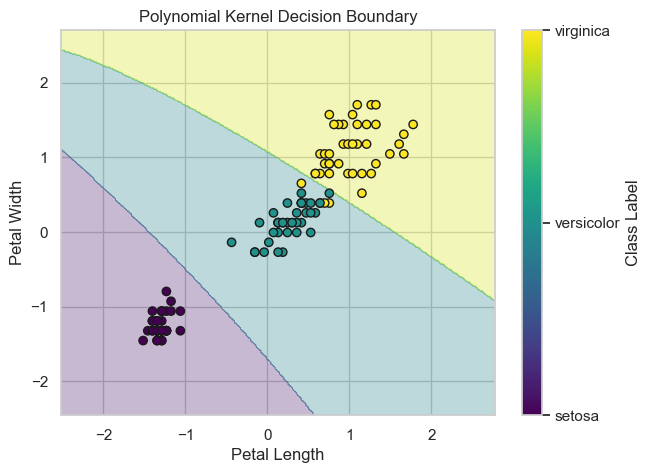

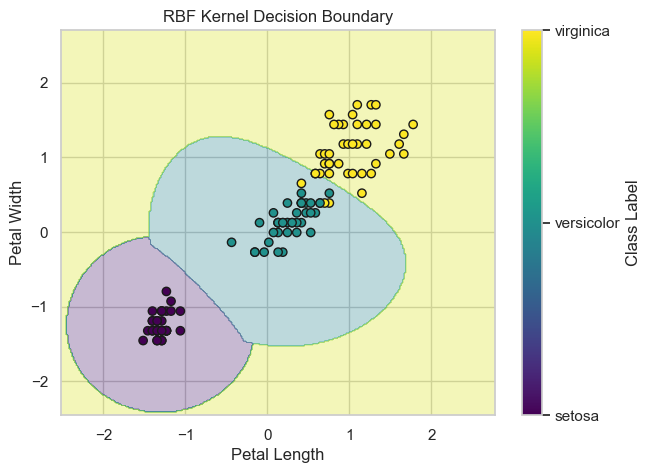

In [33]:
# Visualization and Classification Metrics for Polynomial Kernel and RBF Kernel Metric
poly_svm = OVO_KernelSVM(C=0.1,kernel="poly",degree=2,gamma=1,epochs=5000,lr=0.001)
rbf_svm = OVO_KernelSVM(C=0.1,kernel="rbf",gamma=1,epochs=5000,lr=0.001)

poly_svm.fit(X_train,y_train)
rbf_svm.fit(X_train,y_train)

poly_preds = poly_svm.predict(X_test)
rbf_preds = rbf_svm.predict(X_test)

print("Polynomial Kernel Results\n")

print("Accuracy:",accuracy_score(y_test,poly_preds))
print(confusion_matrix(y_test,poly_preds))
print(classification_report(y_test,poly_preds,target_names=class_names))


print("\nRBF Kernel Results\n")

print("Accuracy:",accuracy_score(y_test,rbf_preds))
print(confusion_matrix(y_test,rbf_preds))
print(classification_report(y_test,rbf_preds,target_names=class_names))

poly_sv = sum(len(clf.alpha) for clf in poly_svm.classifiers.values())
rbf_sv = sum(len(clf.alpha) for clf in rbf_svm.classifiers.values())

print("Polynomial Support Vectors:",poly_sv)
print("RBF Support Vectors:",rbf_sv)

plot_decision_boundary(poly_svm,X_train,y_train,"Polynomial Kernel Decision Boundary")
plot_decision_boundary(rbf_svm,X_train,y_train,"RBF Kernel Decision Boundary")